<a href="https://colab.research.google.com/github/studentradhika/Adaptive-Behavioral-Intelligence-System-for-Resource-Utilization-Optimization/blob/main/Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision gputil pandas matplotlib

  Preparing metadata (setup.py) ... done
  Created wheel for gputil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=01a74da5cf83928ad95ff49bcf39e9dd22a49bab97f9251776b9772ce03ae94a
  Stored in directory: /root/.cache/pip/wheels/92/a8/b7/d8a067c31a74de9ca252bbe53dea5f896faabd25d55f541037
Successfully built gputil


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

import GPUtil
import time
import pandas as pd
import matplotlib.pyplot as plt
import threading

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
gpu_data = []

def monitor_gpu():
    for i in range(50):
        gpus = GPUtil.getGPUs()
        for gpu in gpus:
            gpu_data.append({
                "Time": time.time(),
                "Load (%)": gpu.load * 100,
                "Temperature (C)": gpu.temperature,
                "Memory (MB)": gpu.memoryUsed
            })
        time.sleep(1)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

100%|██████████| 170M/170M [01:30<00:00, 1.88MB/s]


In [ ]:
class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64*6*6, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = x.view(-1, 64*6*6)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [ ]:
model = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
thread = threading.Thread(target=monitor_gpu)
thread.start()
for epoch in range(5):

    running_loss = 0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", running_loss)

thread.join()

Epoch: 1 Loss: 600.5662556886673
Epoch: 2 Loss: 463.3411900997162
Epoch: 3 Loss: 400.1575010418892
Epoch: 4 Loss: 357.6380903124809
Epoch: 5 Loss: 322.66773784160614


In [ ]:
df = pd.DataFrame(gpu_data)
df.to_csv("gpu_full_data.csv", index=False)

print(df.head())

           Time  Load (%)  Temperature (C)  Memory (MB)
0  1.774682e+09       0.0             43.0        127.0
1  1.774682e+09       1.0             43.0        225.0
2  1.774682e+09      23.0             44.0        271.0
3  1.774682e+09      23.0             44.0        271.0
4  1.774682e+09      23.0             44.0        271.0


In [ ]:
gpu_data = []

def monitor_gpu():
    for i in range(20):
        gpus = GPUtil.getGPUs()
        for gpu in gpus:
            gpu_data.append({
                "Time": time.time(),
                "Load (%)": gpu.load * 100,
                "Temperature (C)": gpu.temperature,
                "Memory (MB)": gpu.memoryUsed
            })
        time.sleep(1)

In [ ]:
def monitor_gpu():
    for i in range(20):
        gpus = GPUtil.getGPUs()
        print("Monitoring running...")
        for gpu in gpus:
            print(gpu.temperature)
            gpu_data.append({
                "Time": time.time(),
                "Load (%)": gpu.load * 100,
                "Temperature (C)": gpu.temperature,
                "Memory (MB)": gpu.memoryUsed
            })
        time.sleep(1)

In [ ]:
# Start monitoring
thread = threading.Thread(target=monitor_gpu)
thread.start()

# Run training
for epoch in range(3):
    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

# Wait for monitoring to finish
thread.join()

Monitoring running...
50.0
Monitoring running...
51.0
Monitoring running...
51.0
Monitoring running...
51.0
Monitoring running...
51.0
Monitoring running...
51.0
Monitoring running...
51.0
Monitoring running...
52.0
Monitoring running...
52.0
Monitoring running...
52.0
Monitoring running...
52.0
Monitoring running...
52.0
Monitoring running...
52.0
Monitoring running...
52.0
Monitoring running...
53.0
Monitoring running...
53.0
Monitoring running...
53.0
Monitoring running...
53.0
Monitoring running...
53.0
Monitoring running...
54.0


In [ ]:
print("Collected data:", len(gpu_data))

Collected data: 20


In [ ]:
gpu_data = []

for epoch in range(3):

    print("Epoch:", epoch+1)

    for images, labels in trainloader:

        # 🔹 GPU Monitoring
        gpus = GPUtil.getGPUs()
        for gpu in gpus:
            gpu_data.append({
                "Time": time.time(),
                "Load (%)": gpu.load * 100,
                "Temperature (C)": gpu.temperature,
                "Memory (MB)": gpu.memoryUsed
            })

        # 🔹 Training
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

Epoch: 1
Epoch: 2
Epoch: 3


In [ ]:
print("Collected data:", len(gpu_data))

Collected data: 1173


In [ ]:
gpu_data = []

for epoch in range(3):   # 👈 THIS WAS MISSING
    print("Epoch:", epoch+1)

    for images, labels in trainloader:

        # 🔹 GPU Monitoring
        gpus = GPUtil.getGPUs()

        if len(gpus) == 0:
            print("❌ No GPU detected")

        for gpu in gpus:
            print("Temp:", gpu.temperature)  # debug
            gpu_data.append({
                "Time": time.time(),
                "Load (%)": gpu.load * 100,
                "Temperature (C)": gpu.temperature,
                "Memory (MB)": gpu.memoryUsed
            })

        # 🔹 Training
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

Epoch: 1
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 61.0
Temp: 60.0
Temp: 61.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 60.0
Temp: 61.0
Temp: 61.0
Temp: 60.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 60.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
Temp: 61.0
T

In [ ]:
images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()          # gradients reset

outputs = model(images)        # forward pass

loss = criterion(outputs, labels)  # loss calculate

loss.backward()                # backpropagation

optimizer.step()               # weights update

In [ ]:
for epoch in range(3):
    print("Epoch:", epoch+1)

    for images, labels in trainloader:

        # 🔹 GPU Monitoring
        gpus = GPUtil.getGPUs()
        for gpu in gpus:
            gpu_data.append({
                "Time": time.time(),
                "Load (%)": gpu.load * 100,
                "Temperature (C)": gpu.temperature,
                "Memory (MB)": gpu.memoryUsed
            })

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

Epoch: 1
Epoch: 2
Epoch: 3


In [ ]:
print("Collected data:", len(gpu_data))

Collected data: 2346


In [ ]:
import pandas as pd

df = pd.DataFrame(gpu_data)
print(df.head())

           Time  Load (%)  Temperature (C)  Memory (MB)
0  1.774682e+09       0.0             60.0        273.0
1  1.774682e+09       0.0             60.0        273.0
2  1.774682e+09       0.0             60.0        273.0
3  1.774682e+09       0.0             60.0        273.0
4  1.774682e+09       0.0             60.0        273.0


In [ ]:
def detect_stress(row):
    load = row["Load (%)"]
    temp = row["Temperature (C)"]

    score = (0.6 * load) + (0.4 * temp)

    if score > 80:
        return "High Stress"
    elif score > 50:
        return "Medium Stress"
    else:
        return "Low Stress"

df["Stress_Level"] = df.apply(detect_stress, axis=1)

In [ ]:
def suggest_action(stress):
    if stress == "High Stress":
        return "Reduce batch size / Stop processes"
    elif stress == "Medium Stress":
        return "Monitor GPU"
    else:
        return "Increase workload"

df["Suggestion"] = df["Stress_Level"].apply(suggest_action)

In [ ]:
print(df[["Load (%)","Temperature (C)","Stress_Level","Suggestion"]].head())

   Load (%)  Temperature (C) Stress_Level         Suggestion
0       0.0             60.0   Low Stress  Increase workload
1       0.0             60.0   Low Stress  Increase workload
2       0.0             60.0   Low Stress  Increase workload
3       0.0             60.0   Low Stress  Increase workload
4       0.0             60.0   Low Stress  Increase workload


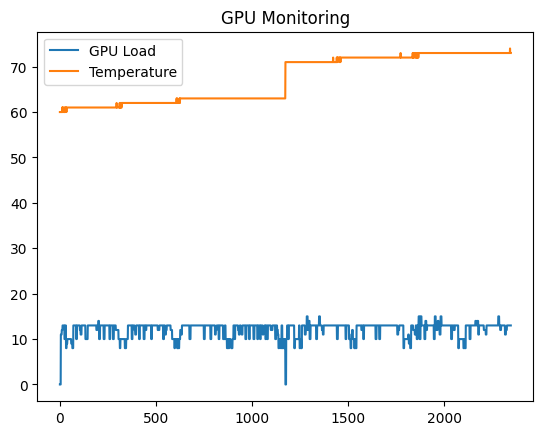

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df["Load (%)"], label="GPU Load")
plt.plot(df["Temperature (C)"], label="Temperature")

plt.legend()
plt.title("GPU Monitoring")
plt.show()

In [ ]:
print("Average Load:", df["Load (%)"].mean())
print("Average Temp:", df["Temperature (C)"].mean())
print(df["Stress_Level"].value_counts())

Average Load: 12.043478260869565
Average Temp: 67.18840579710145
Stress_Level
Low Stress    2346
Name: count, dtype: int64


In [ ]:
df.to_csv("final_gpu_analysis.csv", index=False)

In [ ]:
from google.colab import files
files.download("final_gpu_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.savefig("graph.png")

<Figure size 640x480 with 0 Axes>